# Research: Funding Rate Snipe Project

This notebook will do research about the existence of an edge with crypto funding rates of perpetual futures contracts (perps).

# Exchange

For this project we will use the crypto currency exchange Bitget. Bitget offers small trading fees, while being a large, trustworthy platform.
| Exchange | Spot maker | Spot taker | Perpetual maker | Perpetual taker | Notes |
| --- | ---: | ---: | ---: | ---: | --- |
| Binance | 0.10% | 0.10% | 0.02% | 0.05% | Large liquidity, widely used |
| Bitget | 0.10% | 0.10% | 0.02% | 0.06% | Often competitive for perpetual futures |
| Bybit | 0.10% | 0.10% | 0.02% | 0.055% | Strong perpetuals focus |
| OKX | 0.08% | 0.10% | 0.02% | 0.05% | Competitive fees, broad market |
| Coinbase Advanced | 0.40% | 0.60% | N/A | N/A | Higher retail fees, lower crypto focus |

The fees suggest, that all of the first 4 exchanges could be picked. To further investigate, we will look into a coin that paid out a funding rate around $\pm 1$ and check the trading volume. That is important as a large trading volume will allow us to execute large positions without changing the funding rate nor the contract price.

**STORJUSDT on 24.08.2026 at 22:00**
| Exchange | last funding rate | 24h trading volume |
| --- | ---: | ---: |
| Binance | -1.0986% | 60.965172 Mio $ | 
| Bitget | -1.0862% | 60.562908 Mio $ | 
| Bybit | **different payout time** | **arbitrage opportunity?** | 
| OKX | coin not available | - | 

As fees, funding rates and trading volumes are very similar for BitGet and Binance we can pick any of these two and will proceed with **BitGet**.

# Historical Funding Rate Payouts Analysis: Potential Payoff, Fees, Volume, Spread, Market Movement
For this we will fetch the relevant data of a few different coins with relevant funding rates from Bitget and analyze the data.

- ACEUSDT
- HOMEUSDT
- BICOUSDT

1. Data fetch using Bitget API

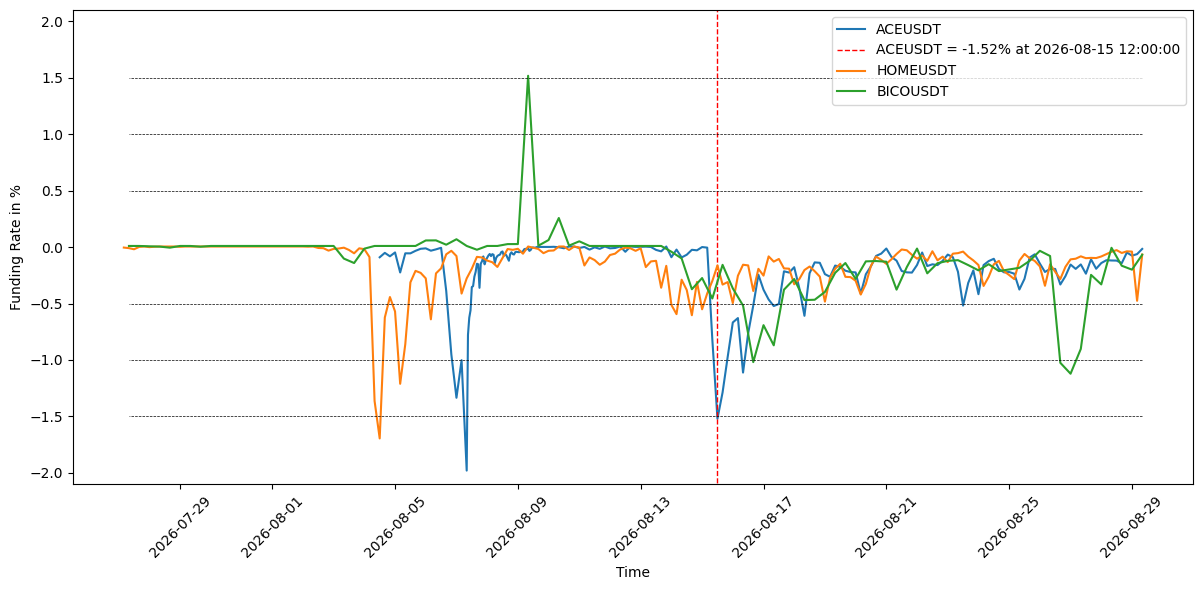

In [24]:
import requests
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt

url = 'https://api.bitget.com/api/v2/mix/market/history-fund-rate'

symbols = ['ACEUSDT', 'HOMEUSDT', 'BICOUSDT']
historical_rates_all = {}
plt.figure(figsize=(12, 6))

for symbol in symbols:
    response = requests.get(
        url,
        params={
            'symbol': symbol,
            'productType': 'USDT-FUTURES',
            'pageSize': 100,
            'pageNo': 1
        }
    )

    historical_rates = response.json().get('data', [])

    timestamps = np.array([datetime.fromtimestamp(int(entry['fundingTime']) / 1000,
    tz=timezone.utc) for entry in historical_rates])
    rates = np.array([float(entry['fundingRate']) for entry in historical_rates])

    period = int(abs((int(historical_rates[1]['fundingTime']) - int(historical_rates[0]['fundingTime'])))/1000/60/60)
    if period == 4:
        response_ = requests.get(
                url,
                params={
                    'symbol': symbol,
                    'productType': 'USDT-FUTURES',
                    'pageSize': 100,
                    'pageNo': 2
                }
            )
        timestamps_ = np.array([datetime.fromtimestamp(int(entry['fundingTime']) / 1000,
        tz=timezone.utc) for entry in response_.json().get('data', [])])
        rates_ = np.array([float(entry['fundingRate']) for entry in response_.json().get('data', [])])
        timestamps = np.concatenate((timestamps, timestamps_))
        rates = np.concatenate((rates, rates_))
        

    historical_rates_all[symbol] = {
        'timestamps': timestamps,
        'rates': rates
    }

    plt.plot(timestamps, np.array(rates)*100, label=symbol)
    plt.xlabel('Time')
    plt.ylabel('Funding Rate in %')
    plt.xticks(rotation=45)
    plt.tight_layout()

    if symbol == 'ACEUSDT':
        args = np.argwhere(abs(np.array(rates)) >= 0.015).flatten()
        # plt.scatter(timestamps[args], np.array(rates)[args]*100, color='red', s=10, label=f'{symbol} > 1.5%')
        plt.vlines([timestamps[args[0]]], -3, 3, color='red', linewidth=1, linestyle='--', label=f'{symbol} = {np.array(rates)[args[0]]*100:.2f}% at {timestamps[args[0]].strftime("%Y-%m-%d %H:%M:%S")}')

plt.ylim(-2.1, 2.1)
plt.hlines([1.5, 1., 0.5, -0.5, -1., -1.5], timestamps[0], timestamps[-1], color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.show()


To be able to say something about a potential profit for a certain funding rate $f$, extreme events for $|f|>\varepsilon$ need to be investigated further regarding:
- $f$ $\rightarrow$ potential relative profit
- perp price movement $\rightarrow$ directional risk
- perp trading volume $\rightarrow$ spread and price distortion risk

The funding rate $f=-1.52 \%$ spike of ACEUSDT at 2026-08-15 12:00:00 is investigated, regarding its spot and perp data.

In [34]:
import requests, time
import pandas as pd
from datetime import datetime, timezone

symbol = 'ACEUSDT'

start_time = datetime(2026, 8, 15, 11, 58, tzinfo=timezone.utc)
end_time = datetime(2026, 8, 15, 12, 2, tzinfo=timezone.utc)

start_ms = int(start_time.timestamp() * 1000)
end_ms = int(end_time.timestamp() * 1000)

BASE = "https://api.bitget.com"

def fetch_fills_history(symbol, product_type, start_ms, end_ms):
    trades_sell = []
    trades_buy = []
    id_less_than = None
    while True:
        params = {"symbol": symbol}
        if id_less_than:
            params["idLessThan"] = id_less_than

        params["startTime"] = start_ms
        params["endTime"] = end_ms

        if product_type== "USDT-FUTURES":
            url = f"{BASE}/api/v2/mix/market/fills-history"
            params["productType"] = product_type
        elif product_type== "USDT-SPOT":  # spot
            url = f"{BASE}/api/v2/spot/market/fills-history"
        else:
            raise ValueError("Invalid product_type. Must be 'USDT-FUTURES' or 'USDT-SPOT'.")

        r = requests.get(url, params=params).json()
        data = r.get("data", [])
        if not data:
            break
        for trade in data:
            if trade["side"] == "Sell":
                trades_sell.append(trade)
            else:
                trades_buy.append(trade)

        id_less_than = data[-1]["tradeId"]
        time.sleep(0.05)  # Rate Limit beachten
    return pd.DataFrame(trades_sell), pd.DataFrame(trades_buy)

df_sell, df_buy = fetch_fills_history(symbol, product_type="USDT-SPOT", start_ms=start_ms, end_ms=end_ms)  # spot
df_sell["ts"] = pd.to_datetime(df_sell["ts"].astype(float), unit="ms")
df_sell["price"] = df_sell["price"].astype(float)
df_sell["size"] = df_sell["size"].astype(float)
df_buy["ts"] = pd.to_datetime(df_buy["ts"].astype(float), unit="ms")
df_buy["price"] = df_buy["price"].astype(float)
df_buy["size"] = df_buy["size"].astype(float)

df_futures_sell, df_futures_buy = fetch_fills_history(symbol, product_type="USDT-FUTURES", start_ms=start_ms, end_ms=end_ms)  # futures
df_futures_sell["ts"] = pd.to_datetime(df_futures_sell["ts"].astype(float), unit="ms")
df_futures_sell["price"] = df_futures_sell["price"].astype(float)
df_futures_sell["size"] = df_futures_sell["size"].astype(float)
df_futures_buy["ts"] = pd.to_datetime(df_futures_buy["ts"].astype(float), unit="ms")
df_futures_buy["price"] = df_futures_buy["price"].astype(float)
df_futures_buy["size"] = df_futures_buy["size"].astype(float)

# FETCHED DATA ARE HISTORICAL BUY AND SELL TRADES!!! 
# NEED TO DISTINGUISH!!! 
# NEED FOR CORRECTION!!!

In [43]:
df_sell = df_sell.sort_values('ts')
df_buy = df_buy.sort_values('ts')

df_futures_sell = df_futures_sell.sort_values('ts')
df_futures_buy = df_futures_buy.sort_values('ts')

In [ ]:
zoom_start = pd.Timestamp("2026-08-15 11:59:00")
zoom_end = pd.Timestamp("2026-08-15 12:01:00")

spot_zoom_sell = df_sell.loc[zoom_start:zoom_end]
spot_zoom_buy = df_buy.loc[zoom_start:zoom_end]
futures_zoom_sell = df_futures_sell.loc[zoom_start:zoom_end]
futures_zoom_buy = df_futures_buy.loc[zoom_start:zoom_end]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

ax1.plot(futures_zoom_sell.index, futures_zoom_sell["price"], label="Perpetual sell")
ax1.plot(futures_zoom_buy.index, futures_zoom_buy["price"], label="Perpetual buy")
ax1.plot(spot_zoom_sell.index, spot_zoom_sell["price"], label="Spot sell")
ax1.plot(spot_zoom_buy.index, spot_zoom_buy["price"], label="Spot buy")
ax1.axvline(pd.Timestamp("2026-08-15 12:00:00"), color="red", linestyle="--")
ax1.set_ylabel("Price (USDT)")
ax1.set_title("ACEUSDT: 30 Seconds Before and After 12:00 UTC")
ax1.legend()

ax2.plot(futures_zoom_sell.index, futures_zoom_sell["size"], label="Perpetual volume")
ax2.plot(spot_zoom_sell.index, spot_zoom_sell["size"], label="Spot volume")
ax2.axvline(pd.Timestamp("2026-08-15 12:00:00"), color="red", linestyle="--")
ax2.set_xlabel("Time")
ax2.set_ylabel("Trade size")

plt.tight_layout()
plt.show()

KeyError: Timestamp('2026-08-15 11:59:00')

In [27]:
deviation = (1-df["price"]/df_futures["price"])*100

print(len(df), len(df_futures), len(deviation))

# Visualize the spot market data with OHLCV bars
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot candlestick chart
ax1.plot(df_futures.index, df_futures["price"], label='Perp')
ax1.plot(df.index, df["price"], label='Spot')
ax1.set_ylabel('Price (USDT)')
ax1.set_title(f'{symbol} Spot Market - Price Movement (2026-08-15 11:50 to 12:10 UTC)')
ax1.legend()

ax2.plot(deviation.index, deviation, label='Deviation', color='orange')
ax2.set_ylabel('Deviation (\\%)')

# Plot trading volume
ax3.plot(df_futures.index, df_futures["size"], label='Perp')
ax3.plot(df.index, df["size"], label='Spot')
ax3.set_xlabel('Time')
ax3.set_ylabel('Volume (BTC)')

plt.tight_layout()
plt.show()



KeyError: 'price'